# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
import pandas as pd # importar librerías
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [3]:
plans.head(5) # mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
users.head(5) # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
usage.head(5) # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
plans.info() # inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
users.info() # inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
usage.info() # inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para Users
print("Cantidad de valores nulos en Users")
print(users.isna().sum())  # Cantidad de valores nulos)
print()
print('Proporción de valores nulos en Users')
print(users.isna().sum() / 4000 * 100) # Proporción de valores nulos)

# cantidad de nulos para usage
print("Cantidad de valores nulos en Usage")
print(usage.isna().sum())  # Cantidad de valores nulos)
print()
print('Proporción de valores nulos en Usage')
print(usage.isna().sum() / 40000 * 100) # Proporción de valores nulos)


Cantidad de valores nulos en Users
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos en Users
user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64
Cantidad de valores nulos en Usage
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos en Usage
id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).

* Users:
    - city. Tenemos un porcentaje de nulos 11.725% se debe de estudiar según lo que se requiera para **dejar como nulos**.
    - churn_date. Tenemos un numero significativo de nulos 85.35%, con lo cual no podemos confiar y se prosigue a **elimina columna**.
* Usage:
    - date. Tenemos un mínimo porsentaje de nulos 0.125% se consideran casas simples y se dejaría como nulos **ignorar**.
    - duration. Tenemos un porcentaje medio de nulos 55.19% se debe de estudiar según lo que se requiera para **imputar**.
    - length. Tenemos un porcentaje medio de nulos 44.740% se debe de estudiar según lo que se requiera para **imputar**.
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [11]:
print(users.describe()) # explorar columnas numéricas de users

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id` : Tenemos 4,000 registros diferentes por lo cual está correcto al tratarse se un ID (identifiacdor).
- La columna `age`: Tenemos valores fuera de rango -999, si observamos que los demás datos están dentro tendremos que hacer un filtro para corregir estos valores negativos.

In [12]:
print(usage.describe()) # explorar columnas numéricas de usage

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- La columna `id`: Contamos con 40,000 datos consecutivos es decir no tenemos faltantes, todos está correcto.
- La columna `user_id`: Tenemos 40,000 registros diferentes por lo cual está correcto al tratarse se un ID (identifiacdor).
- La columna `duration`: Tenemos algunos valores que superan la duración saliéndose del promedio y la media en un gran porcentaje, se tendrán que corregir o ignorar estos datos para el estudio. 
- La columna `length` Tenemos algunos valores que superan la longitud saliéndose del promedio y la media en un gran porcentaje, se tendrán que corregir o ignorar estos datos para el estudio. 

In [13]:
# explorar columnas categóricas de users


columnas_user = ['city', 'plan']

print(users[columnas_user].describe())
print()
print(users[columnas_user].value_counts())



          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595

city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
dtype: int64


- La columna `city`: Tenemos 7 ciudades, y la más común es Bogotá, con 808 registros. En realidad son seis ciudades y una esta con información erronea con '?' o ' '. tenemos 4,000 registros en los cuales 3,531 tiene alguna valor y 469 nulos.
- La columna `plan` Tenemos dos planes "Básico" y "Premium", el plan más comun es "Básico" con 2595 registros.

In [14]:
# explorar columna categórica de usage
print(usage['type'].describe())
print()
print(usage['type'].value_counts()) # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

text    22092
call    17908
Name: type, dtype: int64


- La columna `type`: Tenemos dos tipos de contacto (type) "text" y "call", la opción de texto (text) es mas común con 22,092 registros. no contamos con datos faltantes o nulos.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

**dataset users**  
- `user_id`: No presenta ningún dato invalido ni sentinel esta lista para trabajar.
- `age`: Tenemos un sesgo a la izquierda (sentinels) con valores mínimos de -999 los cuales representan valores erróneos tendremos que hacer in DROP ya que los valores si los dejamos distorsionaría completamente el análisis sin aportar interpretación real.
- `city`: Tenemos 4,000 registros en los cuales 3,531 tiene algún valor y 469 nulos. de los que tienen valor tenemos 96 que contienen valores invaálidos '?' o ' '. Por lo anterior tenemos 3,435 valores correctos y 565 valores que vamos a sustituir por "Desconocido".
- `plane`: No presenta ningún dato invalido ni sentinel esta lista para trabajar.

**dataset usage**  
- `id`: No presenta ningún dato inválido ni sentinel está lista para trabajar.
- `user_id`: No presenta ningún dato inválido ni sentinel está lista para trabajar.
- `duration`: Tenemos in sesgo a la derecha (sentinels) así como una faltande de informacion muy grande de 22,076 mayor al 50% esta informacion no se considera confiable para el estudio así que podemos ignorar esta columna y no utilizarla.
- `length` : Tenemos un sesgo a la derecha (sentinels) así como una faltande de información muy grande de 17,896 casi un 45% esta información no se considera confiable para el estudio así que podemos ignorar esta columna y no utilizarla.
- `type` : No presenta ningún dato inválido ni sentinel esta lista para trabajar.



### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [15]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce', format='%Y/%m/%d')
# completa el código

In [16]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce', format='%Y/%m/%d') # completa el código

In [17]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()


2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`: Tenemos los datos de los años 2022, 2023 y 2024 dentro de rango, no contamos con información del año 2025 y el año 2026 solamente tiene la parcialidad del periodo que ha trascurrido actualmente. No tenemos datos faltantes.

In [18]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date` : Solamente contamos con información del año 2024, contamos con 39950 solamente tenemos 50 registros sin información o nulo. esta información es apta para trabajar a usuarios registrados en 2024 o anterior.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

** Podemos notar que tenemos usuarios de 2022, 2023 y 2024 los cuales se pueden usar y relacionar con nuestra tabla de actividad si ningún problema los usuarios registrados en 2026 no deberian de aparecer en actividad en 2024, pero no hay que hacer nada con el "Users" ya que no afecta el resultado del estudio**

** Podemos notar que tenemos Actividad solamente de 2024 con lo cual nuestro estudio se basará en este año los datos faltantes son un porcentaje muy bajo que se podrían eliminar sin afectar los resultados.**


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [19]:
# Reemplazar -999 por la mediana de age
age_mediana = int(users['age'].median())
users['age'] =users['age'].replace(-999, pd.NA)
users['age'] =users['age'].fillna(age_mediana)
# Verificar cambios
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,48.122250
std,1154.844867,17.690408
min,10000.000000,18.000000
25%,10999.750000,33.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


In [20]:
# Reemplazar ? por NA en city
users["city"] = users["city"].replace("?", pd.NA)
# Verificar cambios
print(users["city"].value_counts(dropna=False))

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [21]:
# Marcar fechas futuras como NA para reg_date

# Primero, identifica las fechas de 2026
fechas_2026 = users['reg_date'].dt.year == 2026
print(f"Fechas de 2026 encontradas: {fechas_2026.sum()}")

# Usa .loc para marcar esas fechas como NA
users.loc[fechas_2026, 'reg_date'] = pd.NaT

# Verifica los cambios
fechas_2026_despues = users['reg_date'].dt.year == 2026
print(f"Fechas de 2026 después de la limpieza: {fechas_2026_despues.sum()}")

# Verificar cambios



Fechas de 2026 encontradas: 40
Fechas de 2026 después de la limpieza: 0


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [22]:
# Verificación MAR en usage (Missing At Random) para duration
usage["duration"].isna().groupby(usage["type"]).sum().sort_values(ascending=False)

type
text    22076
call        0
Name: duration, dtype: int64

In [23]:
# Verificación MAR en usage (Missing At Random) para length
usage["length"].isna().groupby(usage["type"]).sum().sort_values(ascending=False)

type
call    17896
text        0
Name: length, dtype: int64

'duration' y 'length' son MAR(Missing At Random) dependen directamente de 'type' podemos notar que cuando el tipo es 'call' hay valor en 'duration'y sin valor 'length', de lo contario si el tipo es 'text' hay valor en 'length'y sin valor 'duration'. se dejan como nulos ya que podemos considerar este conclusion en nuestro analisis.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [24]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = pd.DataFrame()
usage_agg = usage.groupby('user_id').agg(
    cant_mensajes=('is_text', lambda x: (x).sum()),
    cant_llamadas=('is_call', lambda x: (x).sum()),
    cant_minutos_llamada=('duration', 'sum')
).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [25]:
# Renombrar columnas
# Ya estab desde el paso anterior
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.set_index('user_id').join(
    usage_agg.set_index('user_id'), 
    how='left'
)
user_profile.head(5)

,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
user_id,,,,,,,,,,
10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [27]:
# Resumen estadístico de las columnas numéricas
print(user_profile.describe())

               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.000000    3999.000000    3999.000000           3999.000000
mean     48.122250       5.524381       4.478120             23.317054
std      17.690408       2.358416       2.144238             18.168095
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.120000
50%      47.000000       5.000000       4.000000             19.780000
75%      63.000000       7.000000       6.000000             31.415000
max      79.000000      17.000000      15.000000            155.690000


In [28]:
# Distribución porcentual del tipo de plan
distribucion_planes = user_profile['plan'].value_counts(normalize=True) * 100
print("Distribución porcentual del tipo de plan:")
print(distribucion_planes)

Distribución porcentual del tipo de plan:
Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

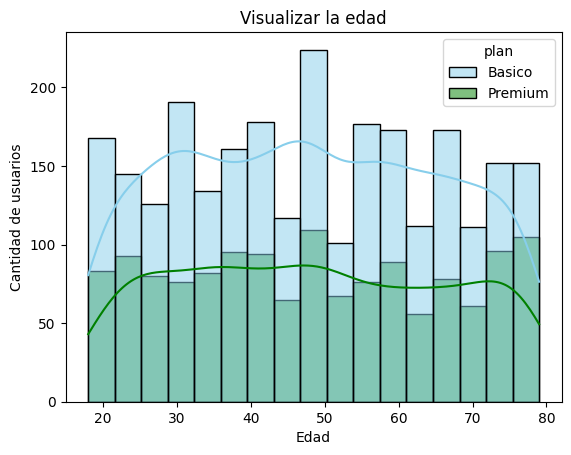

In [29]:
# Histograma para visualizar la edad (age)
sns.histplot(user_profile, x='age', hue='plan', palette=['skyblue','green'], kde=True)

plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.title('Visualizar la edad')

plt.show()

💡Insights: 
- Distribución Simétrica (valores equilibrados a ambos lados).
- Podemos notar que los usuarios que mas ocupan nuestro servicio tienen 47 años aproximadamente.
- Se puede notar que el plan Basico es el que más ocupan nuestros usuarios.

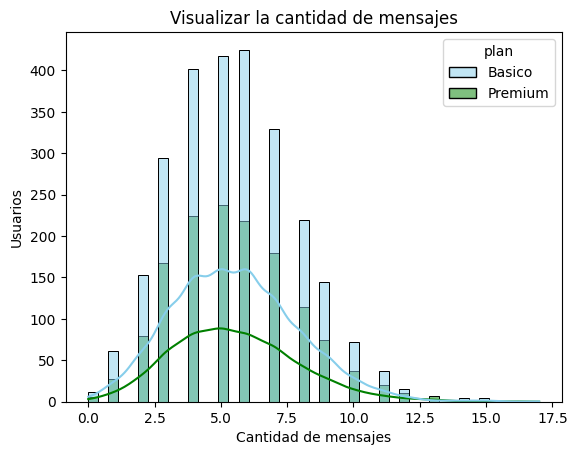

In [30]:
# Histograma para visualizar la cant_mensajes
sns.histplot(user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'], kde=True)

plt.xlabel('Cantidad de mensajes')
plt.ylabel('Usuarios')
plt.title('Visualizar la cantidad de mensajes')

plt.show()

💡Insights: 
- Sesgada a la derecha (cola larga hacia valores altos: cant_mensajes).
- Podemos notar que los usuarios que los usuarios que la media esta aproximadamente en 6 mensajes.
- Se puede notar que el plan Básico es el que más ocupan nuestros usuarios.

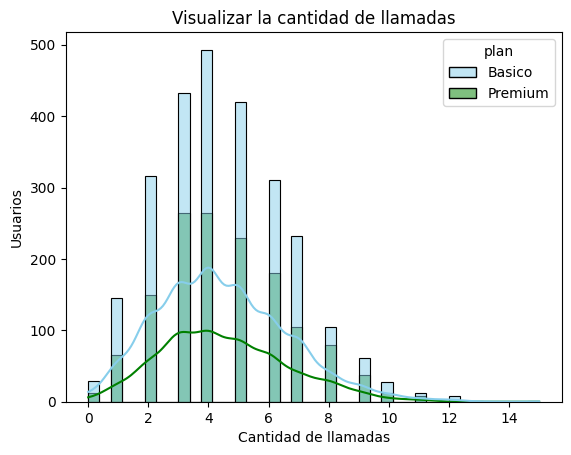

In [31]:
# Histograma para visualizar la cant_llamadas
sns.histplot(user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'], kde=True)

plt.xlabel('Cantidad de llamadas')
plt.ylabel('Usuarios')
plt.title('Visualizar la cantidad de llamadas')

plt.show()

💡Insights: 

- Sesgada a la derecha (cola larga hacia valores altos: cant_llamadas).
- Podemos notar que los usuarios están dentro de la la media, aproximadamente en 4 llamada.
- Se puede notar que el plan Básico es el que más ocupan nuestros usuarios.


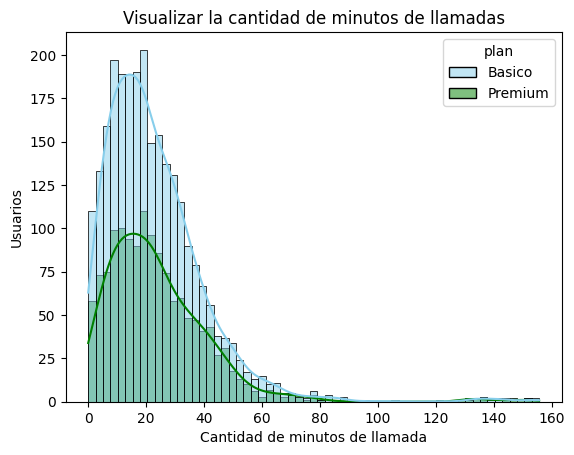

In [32]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'], kde=True)


plt.xlabel('Cantidad de minutos de llamada')
plt.ylabel('Usuarios')
plt.title('Visualizar la cantidad de minutos de llamadas')


plt.show()

💡Insights: 
- Sesgada a la derecha (cola mucho más extendida que los otras mediciones hacia valores altos: cant_minutos_llamada).
- Podemos notar que los usuarios que están dentro de la media están aproximadamente en 20 minutos de llamada.
- Se puede notar que el plan Básico es el que más ocupan nuestros usuarios.


### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

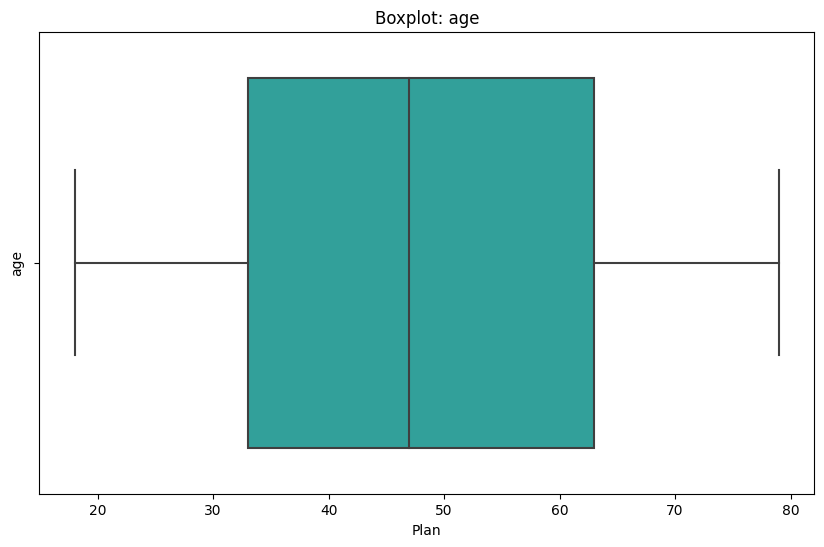

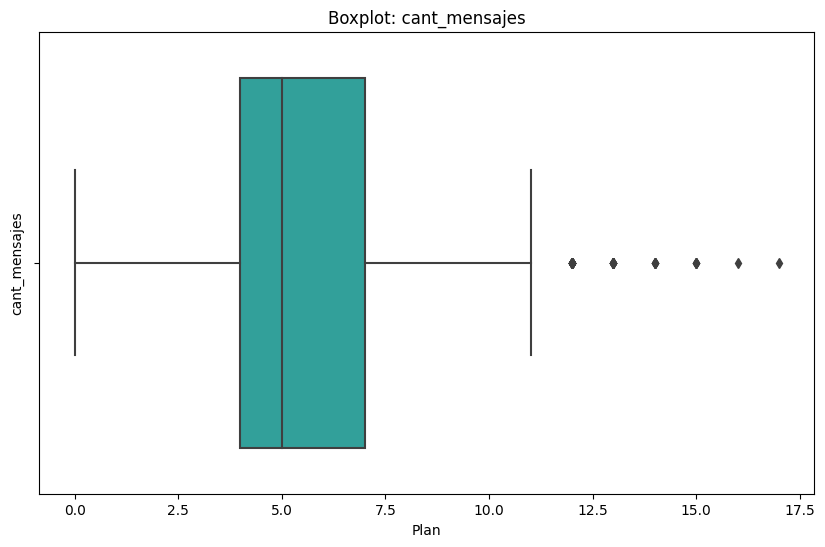

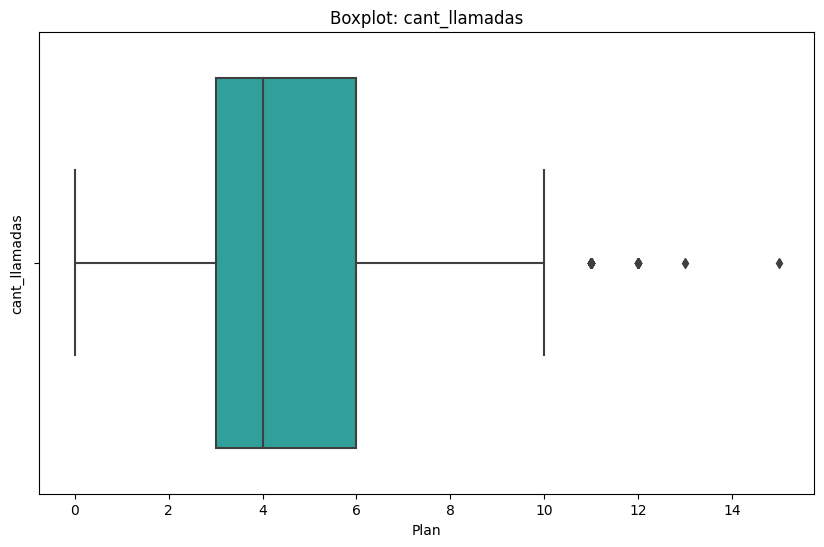

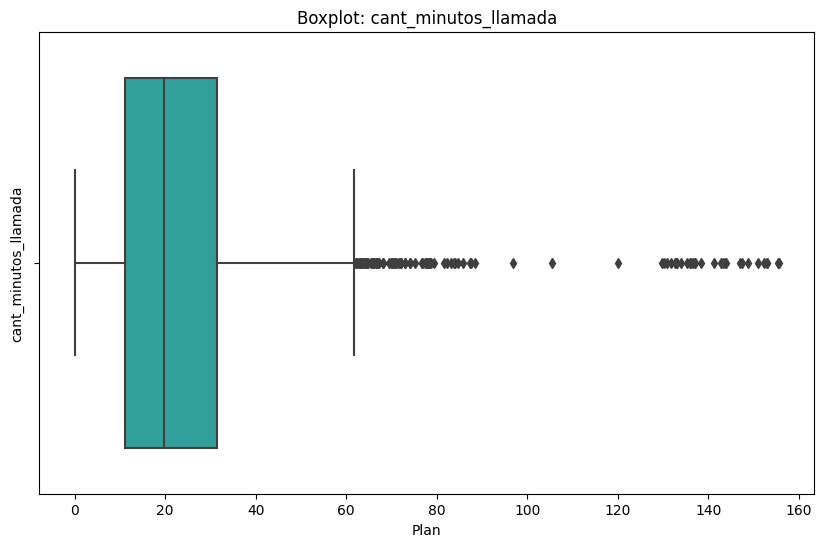

In [33]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for columnas_numericas in user_profile.select_dtypes(include=['float64', 'int64']).columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=user_profile[columnas_numericas], color='lightseagreen')
    plt.title(f'Boxplot: {columnas_numericas}')
    plt.xlabel('Plan')
    plt.ylabel(columnas_numericas)
    plt.show()

💡Insights: 
- Age: No presenta outliers. 
- cant_mensajes: Si presenta outliers. Sesgada a la derecha. 
- cant_llamadas: Si presenta outliers. Sesgada a la derecha. 
- cant_minutos_llamada: Si presenta outliers. Sesgada a la derecha. 

In [34]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for columnas_limites in user_profile.select_dtypes(include=['float64', 'int64']).columns:
    Q1 = user_profile[columnas_limites].quantile(0.25)
    Q3 = user_profile[columnas_limites].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    outliers =user_profile[(user_profile[columnas_limites] > upper_bound)]
    print("Outliers en", columnas_limites, ":")
    display(outliers)
    # Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
    print(user_profile[columnas_limites].describe())
    


Outliers en age :


,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
user_id,,,,,,,,,,


count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64
Outliers en cant_mensajes :


,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
user_id,,,,,,,,,,
10315,Carlos,Lopez,30,MTY,2022-03-28 06:04:03.060765192,Basico,NaN,13.0,3.0,12.36
10347,Carlos,Garcia,77,Cali,2022-04-06 00:21:36.324081021,Basico,NaN,13.0,3.0,21.40
10356,Mateo,Garcia,42,CDMX,2022-04-08 11:30:17.554388598,Basico,NaN,12.0,5.0,59.48
10384,Sofia,Ramirez,35,CDMX,2022-04-16 03:30:39.159789948,Premium,NaN,12.0,3.0,13.05
10456,Mateo,Ramirez,47,CDMX,2022-05-05 20:40:09.002250564,Basico,"1,72653E+18",12.0,1.0,2.24
10539,Sofia,Ramirez,77,Cali,2022-05-28 14:06:55.903975994,Basico,NaN,14.0,5.0,8.66
10591,Ana,Gomez,25,NaN,2022-06-11 19:50:27.456864216,Basico,NaN,12.0,2.0,16.52
10670,Carlos,Torres,47,Bogotá,2022-07-03 11:00:02.700675170,Basico,NaN,12.0,3.0,19.13
10903,Carlos,Lopez,63,CDMX,2022-09-05 06:11:36.774193548,Premium,"1,72938E+18",12.0,3.0,8.89


count    3999.000000
mean        5.524381
std         2.358416
min         0.000000
25%         4.000000
50%         5.000000
75%         7.000000
max        17.000000
Name: cant_mensajes, dtype: float64
Outliers en cant_llamadas :


,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
user_id,,,,,,,,,,
10116,Ana,Garcia,52,CDMX,2022-02-01 18:18:38.079519880,Basico,NaN,3.0,11.0,44.32
10417,Luis,Garcia,70,Bogotá,2022-04-25 04:22:30.337584396,Basico,NaN,4.0,12.0,26.42
10777,Sofia,Lopez,65,Cali,2022-08-01 18:09:59.549887472,Basico,NaN,4.0,12.0,55.28
10778,Mateo,Lopez,77,NaN,2022-08-02 00:44:17.464366092,Basico,NaN,8.0,11.0,32.13
10862,Luis,Ramirez,23,Bogotá,2022-08-25 00:45:22.280570144,Basico,NaN,4.0,15.0,78.11
11013,Mateo,Lopez,65,CDMX,2022-10-05 09:04:27.366841712,Basico,NaN,4.0,11.0,60.83
11564,Carlos,Lopez,41,CDMX,2023-03-05 06:02:58.244561144,Basico,NaN,8.0,11.0,30.17
11614,Mateo,Garcia,73,Bogotá,2023-03-18 22:37:53.968492128,Basico,NaN,5.0,11.0,41.80
11912,Mariana,Garcia,48,Medellín,2023-06-08 12:58:52.483120784,Premium,NaN,2.0,11.0,65.71


count    3999.000000
mean        4.478120
std         2.144238
min         0.000000
25%         3.000000
50%         4.000000
75%         6.000000
max        15.000000
Name: cant_llamadas, dtype: float64
Outliers en cant_minutos_llamada :


,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
user_id,,,,,,,,,,
10027,Ana,Gomez,28,MTY,2022-01-08 09:26:03.690922730,Premium,NaN,8.0,7.0,84.77
10085,Carlos,Ramirez,65,GDL,2022-01-24 06:35:22.730682670,Basico,NaN,6.0,5.0,152.36
10093,Ana,Torres,67,Medellín,2022-01-26 11:09:46.046511628,Basico,NaN,2.0,7.0,71.57
10189,Mariana,Torres,63,MTY,2022-02-21 18:02:25.836459115,Basico,NaN,9.0,4.0,155.42
10198,Sofia,Gomez,58,Medellín,2022-02-24 05:11:07.066766692,Basico,"1,73033E+18",8.0,9.0,78.77
...,...,...,...,...,...,...,...,...,...,...
13920,Mariana,Lopez,48,Bogotá,2024-12-09 08:50:24.756189056,Premium,NaN,4.0,5.0,132.72
13927,Mariana,Lopez,18,GDL,2024-12-11 06:50:30.157539392,Basico,"1,72549E+18",8.0,4.0,135.96
13945,Luis,Ramirez,30,Bogotá,2024-12-16 05:07:52.618154544,Basico,NaN,7.0,3.0,133.97


count    3999.000000
mean       23.317054
std        18.168095
min         0.000000
25%        11.120000
50%        19.780000
75%        31.415000
max       155.690000
Name: cant_minutos_llamada, dtype: float64


In [35]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
# user_profile[columnas_limites].describe()
# Esta arriba en el bucle


💡Insights:
- cant_mensajes: mantener o no outliers, por qué? Cambiar valores extremos por un límite superior (P.99), por que los extremos van a dominar los gráficos/estadísticas. Se considera un valor posible pero extremo así que podemos capar (CAP) para estabilizar sin perder información.
- cant_llamadas: mantener o no outliers, por qué? Cambiar valores extremos por un límite superior (P.99), por que los extremos van a dominan los gráficos/estadísticas. Se considera un valor posible pero extremo así que podemos capar (CAP) para estabilizar sin perder información.
- cant_minutos_llamada: mantener o no outliers, por qué? Cambiar valores extremos por un límite superior (P.99), por que los extremos van a dominar los gráficos/estadísticas. Se considera un valor posible pero extremo así que podemos capar (CAP) para estabilizar sin perder información.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [36]:
# Crear columna grupo_uso
bajo_uso = (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5)
uso_medio = (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)

user_profile['grupo_uso'] = np.where(
    bajo_uso, 'Bajo uso',
    np.where(uso_medio, 'Uso medio', 'Alto uso')
)

In [37]:
# verificar cambios
user_profile.head()
# print(user_profile['grupo_uso'].value_counts()) # Se uso para Analisis.

,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
user_id,,,,,,,,,,,
10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [38]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
    user_profile['age'] < 30, 'Joven',
    np.where(user_profile['age'] < 60, 'Adulto', 'Adulto Mayor')
)

# lo siguiente se uso para el análisis final.
#columnas_estudio = ['grupo_uso', 'grupo_edad', 'plan']
#print(user_profile[columnas_estudio].describe())
#print()
#print(user_profile[columnas_estudio].value_counts())


In [39]:
# verificar cambios
user_profile.head()
# print(user_profile['grupo_edad'].value_counts()) Se uso para Analisis.

,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
user_id,,,,,,,,,,,,
10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

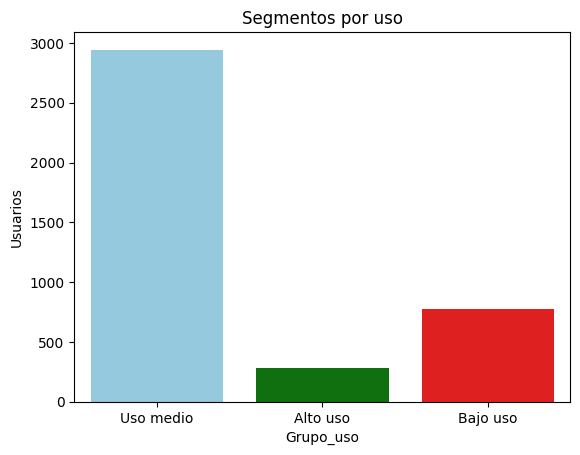

In [40]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x=user_profile['grupo_uso'], palette=['skyblue','green', 'red'])
plt.xlabel('Grupo_uso')
plt.ylabel('Usuarios')
plt.title('Segmentos por uso')
plt.show()

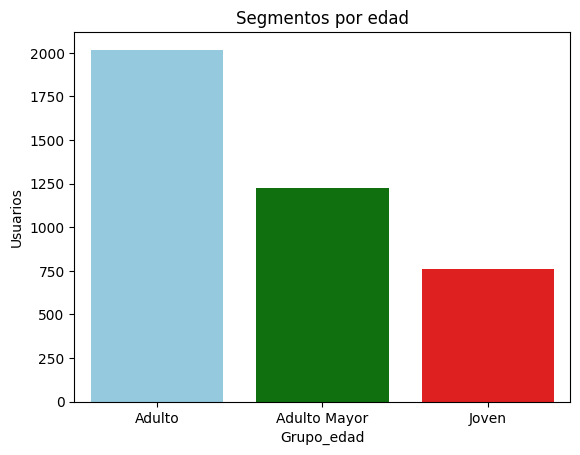

In [41]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x=user_profile['grupo_edad'], palette=['skyblue','green', 'red'])
plt.xlabel('Grupo_edad')
plt.ylabel('Usuarios')
plt.title('Segmentos por edad')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Users (Información de clientes):
    - city (Ciudad).Tenemos un porcentaje de nulos 11.725% de 4,000 registros presenta 469 nulos.
    - churn_date (Fecha de registro). Tenemos un número significativo de nulos 85.35% de 4,000 registros presenta 3,534 nulos.
- Usage (Uso real):
    - date(Fecha del uso). Tenemos un mínimo porcentaje de nulos 0.125% de 40,000 registros presenta 50 nulos.
    - duration (Duracion de la llamada). Tenemos un porcentaje medio de nulos 55.19% de 40,000 registros presenta 22,076 nulos. Aunque son nulos en nuestro df no afecta ya que demenden del tipo de uso en este caso 'call'
    - length (Longitud de los mensajes). Tenemos un porcentaje medio de nulos 44.740% de 40,000 registros presenta 17,896 nulos.

🔍 **Segmentos por Edad**
- El segmento que más uso tiene de nuestros servicios son los 'Adultos' el cual se contempla en de 30 hasta 59 años con 2,018 de 4,000 usuarios.
- Nuestro comportamiento real es el siguinete:
    - Adulto          2018
    - Adulto Mayor    1222
    - Joven            760

📊 **Segmentos por Nivel de Uso**
- El segmento de uso de nuestros servicios fue en un nivel medio, esto se considera en base al uso de 5 a 9 mensajes y 5 a 9 llamadas, con 2,943 usos para 4,000 usuarios.
- Nuestro comportamiento real es el siguinete:
    - Uso medio    2943
    - Bajo uso      778
    - Alto uso      279

📊 **Segmento más valioso para ConnectaTel**
- El segmento por edad que el cual es más valioso para ConnectaTel es los Adultos ya que es la mayoría de nuestros clientes que en el segmento de uso así como en los dos planes que tenemos tiene una mayor participación en nuestra empresa. también este segmento presenta la mayor confianza para el uso de nuestros servicios tanto de llamadas como mensajes.


📊 **Patrones de uso extremo (outliers)**
- Contamos con outliers por usuario en cantidad de mensajes, cantidad de llamadas y suma de minutos de las llamadas, por el porcentaje de registros podemos considerar que los valores extremos no presentan ningún riezgo en el análisis, en los tres casos se sustituyen los valores extremos por el límite superior (P.99) para que no dominen los gráficos/estadísticas.
  
💡 **Recomendaciones**
- Se recomienda poder generar nuevas promociones a nuestros usuarios 'Adultos' para que incrementen el nivel de sus planes y poder obtener mayores ingresos en ConnectaTel. Lo anterior basándonos en que todos los segmentos que estudiamos son nuestros clientes más fieles y que usan más nuestros servicios.
- En el segmentode 'Jóvenes' hay que buscar captación de este segmento buscando que nuestros servicios sean más atractivos para ellos por ejemplo en el uso de redes sociales que estén incluidos.
- En nuestro segmanto de 'Adultos Mayores' al tener un uso menor no necesitaría un mejor plan pero si algún servicio de asesoría por ejemplo médica vía telefónica.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`